## Lojistik Regresyon 

Temel mantık, değişkenin bir sınıfa ait olup olmadığının tespitidir. Yani verilen featureslara bakılarak, sonucu yani targetı tahmin etmek.

Aslında Lojistik Regresyonun mantığı şu şekilde: öncelikle datasete Lineer Regresyon uygulanır, daha sonrasında Sigmoid Fonksiyonu uygulanarak değerler 0-1 arasına indirgenir. <p>
    **Model çıktısı: <p>
        0.8 -> %80 ihtimalle 1<p>
        0.2 -> %20 ihtimalle 1 <p>
        Threshold 0.5 olduğundan eğer 0.5'ten büyük ise 1 değil ise 0 şeklinde.

### Lojistik Regresyon Performans Metrikleri

#### Confusion Matrix

Confusion Matrix, sınıflandırmla problemlerinde modelin doğru ve yanlış tahminlerini 4 farklı sınıfa ayırır.

    -- True Positive (TP): Gerçek değer pozitif, tahmin pozitif.
            -- Yani ben sınavdan geçecek demişim, sınavdan da geçmiş.
    -- True Negative (TN): Gerçek değer negatif, tahmin de negatif.
            -- Yani ben sınavdan geçecek kalacak demişim, sınavdan da kalmış.
    -- False Positive (FP): Gerçek değer negatif, tahmin pozitif.
            -- Yani ben sınavdan geçecek geçecek demişim, sınavdan da kalmış.
    -- False Negative (FN): Gerçek değer pozitif, tahmin negatif.

Data setine göre değişmekle beraber TP ve TN genelde yüksek olmasını isteriz, ancak örneğin dataset hastalık ile alakalı konu ise FN'in de yüksek olmasını isteriz. Yani datasete göre değişebilecek bir konu. 

##### Accuracy (Doğruluk)

Genel olarak modelin ne kadar doğru tahmin yaptığını gösterir, ancak dengesiz veri setinde yanıltıcı olabilir.

Accuracy = TP + TN / TP + TN + FP + FN

##### Precision (Kesinlik)

Modelin pozitif tahminleri arasında, kaç tanesinin gerçekten pozitif olduğunu ölçer.

Precision = TP / TP + FP --> Negatif neden yok? Çünkü öyle bir dataset ki benim için pozitif tahminler çok çok önemli ise bu metriğe bakılmalı.

##### Precision'ın Önemli Olduğu Durum

-- Spam sınıflandırma: Gerçek spam olmayan e-postaların spam sınıfına gönderilmesi. Yani ben spam diyorum aslında değil. 1 diyorum aslında 0. Dolayısıyla bu durumda FP azaltılmalı: Precision yüksek olmalı.

##### Recall (Duyarlılık)

Gerçek pozitif örneklerden, kaç tanesini modelin tahmin ettiğini ölçer.

Recall = TP / TP + FN --> FN eklenmesi şu: yanlışlıkla 0 denmesi aslında. 

Diyabet modellemesi düşünelim, hastaya yanlışlıkla sen hasta değilsin denmesi hayati sonuca mal olabilir. Dolayısıyla burada da modelin doğrularını test ederiz.

##### Recall'ın Önemli Olduğu Durum

-- Hasta bir bireyin sınıflandırılması: Hasta bir bireyi hasta değil olarak sınıflandırmak ciddi bir hatadır. FN azaltılmalı --> Recall yüksek olmalıdır.

##### F1 Score

Hem kesinlik hem de duyarlılık önemli ise bu metrik kullanılır. Formülde beta var. F-skor 1'e yaklaştıkça hem precision hem de recallda güçlü demek olur, 0'a yaklaştıkça ikisinde de kötü anlamına gelir. 

Eğer betayı; <p> B < 1: Precision Önemli <p>
            B > 1: Recall önemli

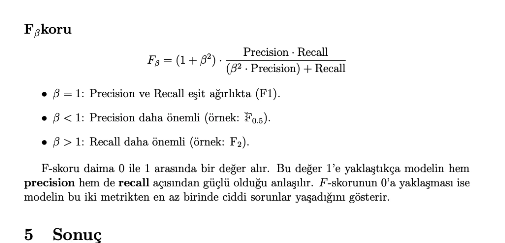

""" 
Logistic Regression Parametreleri

### penalty (overfittingi engellemek)

--l2 (ridge default olarak bu var), l1(lasso) veya elasticnet
--overfittingi nasıl engelleneceğine yönelik seçim yapılmasını sağlar.

### C (regularization gücü)

Penaltylerin lamba oranları, yani ne kadar güçlü ceza vereceğiz.

--Küçük C --> güçlü regularization --> model daha basit --> overfit azalır
--Büyük C --> az regulariation --> model daha kompleks --> overfit artar

### solver (optimizasyon algoritması)

Modelin nasıl öğreneceği belirtilir.

--liblinear --> küçük dataset + l1 destekler
--lbfgs --> default bu, genelde iyi çalışır.
--saga --> büyük dataset + elasticnet destekler

### max_iter

Modelin kaç iterasyon deneyeceği.

### class_weight

Dengesiz veri setinde kullanılır, az olan sınıflarda çok kritik (kanser vb)

"balanced" olması az olan sınıfa önemi arttırır.

### multi_class

Çok sınıflı problemler için geçerlidir. 

"ovr" --> One vs Rest

"multinominal" --> softmax yaklaşımı



"""

### ROC-AUC

ROC Curve threshold değerlerinin değişimine göre çıkartılan bir grafiktir. Eşik değeri değiştiği durumlarda yani eşik değere göre FP FN gibi değerlerin nasıl değiştiğini gösterir.

X ekseni --> FPR (False Positive Rate) <p>

Y ekseni --> TPR (True Positive Rate) <p>

Yani ROC eğrisi tüm threshold değerleri için bir grafik eğrisi çizer.

AUC ise ROC Curveün altında kalan alan demek oluyor. Eğer AUC = 1 ise perfect 0.5 ise random.

| AUC       | Anlam           |
| --------- | --------------- |
| 0.5       | Rastgele tahmin |
| 0.6 - 0.7 | Zayıf           |
| 0.7 - 0.8 | Orta            |
| 0.8 - 0.9 | İyi             |
| 0.9+      | Çok iyi         |

Sonuç olarak ROC-AUC aslında şunu ölçüyor; Model, rastgele seçilen bir pozitif örneği, rastgele seçilen bir negatif örnekten daha yüksek bir skorla sıralayabiliyor mu? Yani burada amaç modelin sıralama gücünü değerlendirmek. Dolayısılya accuracy'den daha sağlam bir model performans metriğidir.


## Support Vector Machines (SVM)

Tanım: SVM, hem sınıflandırma hem de regresyon problemlerinde kullanılan küçlü bir ML algoritmasıdır. 

İki veri kümesi düşün ayrı ayrı, bu veri kümesinin tam ortasından çekilen çizgi 2'ye ayırır bu kümeyi.
Çizginin sağında ve solundaki en yakın veri kümesinden çekilen çizgi(destek vektörü) ile ortadaki best fit line aralığına margin aralığı denir.

Margin aralığının max olduğu aralığa ulaşmak gerekir. Dolayısıyla margini max etmek ve w'yı minimize etmektir.

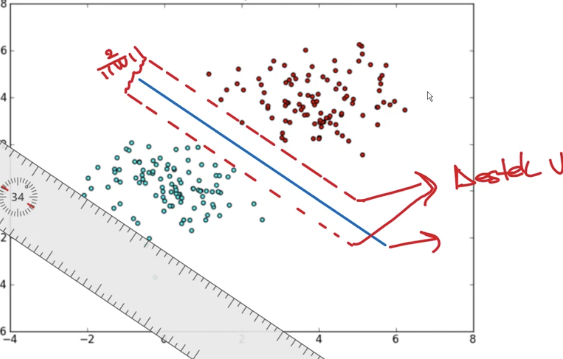

#### Vektörel Gösterim

Doğrusal modellerde gösterim y = A0+A1X idi. Ancak SVM'de w^T * X + b = 0 <p>

w^T --> Ağırlıklar vektörünün transpozesi. Matrix çarpımı yapıyor yani, çarpım yapabilmek için transpoze etmesi gerekiyor. <p>

X --> girdi özelliklerinin vektörü <p>

b --> sabit terim veya bias <p>

### Hyperparametreler

#### C Values 

Küçük C (0.01, 0.1) <p>

Daha fazla hataya izin verir, overfitting düşük underfitting yüksek olabilir. Daha smooth karar sınırı olur. Yani ana mantık: her nokta doğru sınıflandırılsın mı yoksa biraz hata kabul edilsin mi. Soft veya hard margin konusu burada geçerlidir. 

##### Soft Margin

Destek vektörlerin iç kısımı, yani margin aralığındaki boşluğa herhangi bir veri girmesini kabul eden durumdur. Gerçek dünyaya daha yakın olan margin tipi budur.

##### Hard Margin

Margin arasına herhangi bir noktanın girişinin kabul edilmesi anlamına gelir.

SVC: Support Vector Classifier --> Margin boşluğunu maksimize etmeye çalışır. <p>
SVR: Support Vector Regression --> Lineer regresyonda mantık, best fit line'a yakınlık olmasıydı, burada da best fit lineın iki tarafından da bir çizgi çizerek tüp oluşturur. Bu tüpün içinde kalan alan baz alınır.

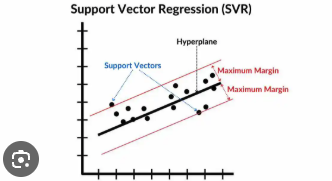

#### Kernel Trikleri

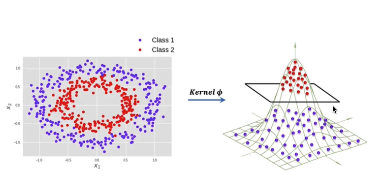

Yukarıdaki gibi bir dataset düşünelim, veriler iç içe birbiriyle iç içe girmiş yani. Kernel trik, veri noktalarının ya üssünü alarak ya da matematik fonksiyonu kullanarak boyutları yükseltir ve sağdaki hale getirir. Böylece yüksek başarı ile iki veri birbirinden ayrılmış olur.

**linear <p>
-- Target değişkende linear bir ilişki var ise kullanılır, büyük veri setlerinde hızlıdır.

** rbf <p>
-- Non-linear ilişkileri yakalar.

#### Gamma (rbf, poly ve sigmoid için)

Tanım: tek bir noktanın etki alanını belirler.

***Küçük gamma (0.001) <p>
-- Daha geniş etki alanı olur ve boundary smoothtur. Verilerin birbirine karşı etki alanını belirtir. Örneğin gamma küçük ise en uzaktaki iki veri bile birbirini etkiler.

***Büyük gamma (1,10) <p>
-- Noktalar daha lokal etkilidir, boundry kıvrımlı olur ve verilerin tam uyum sağlamasına force eder. Dolayısıyla overfitting riski yüksektir.